# Recommender Systems from Scratch

A recommender predicts how much a user would like something they have not seen. The data is a
matrix $R$ with one row per user, one column per item, and a rating in the cells where a user has
actually rated an item.

The defining feature of the problem is that **almost every cell is empty**. In the data used here
6,040 users have rated 3,706 films 1,000,209 times, which fills 4.5% of the matrix. The other
95.5% is what we are asked to predict, and it is not missing at random - people watch films they
expect to like.

The size matters for what follows. A smaller version of this dataset exists with 100,000 ratings,
and on it the last two models in this notebook come out tied, because the median film has only 27
ratings - too little evidence to support a rich description of it. Here the median film has 124,
which is what lets the later models separate from the baseline.

That emptiness is why this is not ordinary regression. There is no feature vector describing a
user and no target column to fit. The only signal is the pattern of which cells are filled and
what is in them, so the model has to infer both what each item is like and what each user wants
from the ratings alone.

Three approaches are built here, in increasing order of what they assume:

1. **Baselines** - every rating is the global average, adjusted by how generous the user is and
   how well-liked the item is. No interaction between the two.
2. **Neighbourhood collaborative filtering** - items that are rated similarly by the same people
   are similar, so predict from the user's own ratings of similar items.
3. **Matrix factorisation** - explain the whole matrix with a small number of hidden factors, so
   each user is a short vector of tastes and each item a short vector of attributes.

The result worth stating up front: the third method is the most sophisticated and beats the first
by about 3%. That gap is the honest measure of what all this machinery buys.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style

style.use('ggplot')
colors = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#4a3aa7']
np.random.seed(0)

## Loading the data

`u.data` has one rating per line: user id, item id, rating from 1 to 5, and a timestamp. The ids
start at 1, so subtracting 1 turns them into row and column indices. `u.item` is pipe-separated
with the film title in the second field and 19 genre flags in the last 19, which are used later to
check what the model learned.

In [2]:
# ratings.dat is "user::item::rating::timestamp"
rows = []
with open('../data/movielens/ml-1m/ratings.dat', encoding='latin-1') as f:
    for line in f:
        a, b, c, _ = line.rstrip('\n').split('::')
        rows.append((int(a), int(b), float(c)))
rows = np.array(rows)

# ids are not contiguous, so map them down to 0..n-1
raw_u = rows[:, 0].astype(np.int64)
raw_i = rows[:, 1].astype(np.int64)
u_map = {v: k for k, v in enumerate(np.unique(raw_u))}
i_map = {v: k for k, v in enumerate(np.unique(raw_i))}

users = np.array([u_map[x] for x in raw_u])
items = np.array([i_map[x] for x in raw_i])
ratings = rows[:, 2]

n_users = len(u_map)
n_items = len(i_map)

# movies.dat is "id::title::genre|genre|..."
genre_names = ['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime',
               'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
               'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
titles = np.empty(n_items, dtype=object)
genres = np.zeros((n_items, len(genre_names)), dtype=int)
with open('../data/movielens/ml-1m/movies.dat', encoding='latin-1') as f:
    for line in f:
        mid, title, gs = line.rstrip('\n').split('::')
        mid = int(mid)
        if mid not in i_map:
            continue                      # a few films have no ratings at all
        j = i_map[mid]
        titles[j] = title
        for gname in gs.split('|'):
            if gname in genre_names:
                genres[j, genre_names.index(gname)] = 1

print('ratings:', len(ratings))
print('users:  ', n_users)
print('items:  ', n_items)
print('density: %.4f' % (len(ratings) / (n_users * n_items)))
print('mean rating: %.4f' % ratings.mean())

ratings: 1000209
users:   6040
items:   3706
density: 0.0447
mean rating: 3.5816


## What the data looks like

Three things about this data drive every design decision later.

The **ratings are not balanced**: 4 is the most common score and only 6% of ratings are a 1, so a
model that always guesses somewhere near 4 is already half right. The **counts per user and per
item are extremely skewed**: a few hundred films collect most of the ratings while most films are
rated a handful of times, and the same is true of users. And the **matrix is almost entirely
empty**, which the sampled block below makes visible.

The skew matters because any similarity computed from two or three shared ratings is mostly noise,
and because the items with plenty of data are exactly the ones a popularity baseline already
handles.

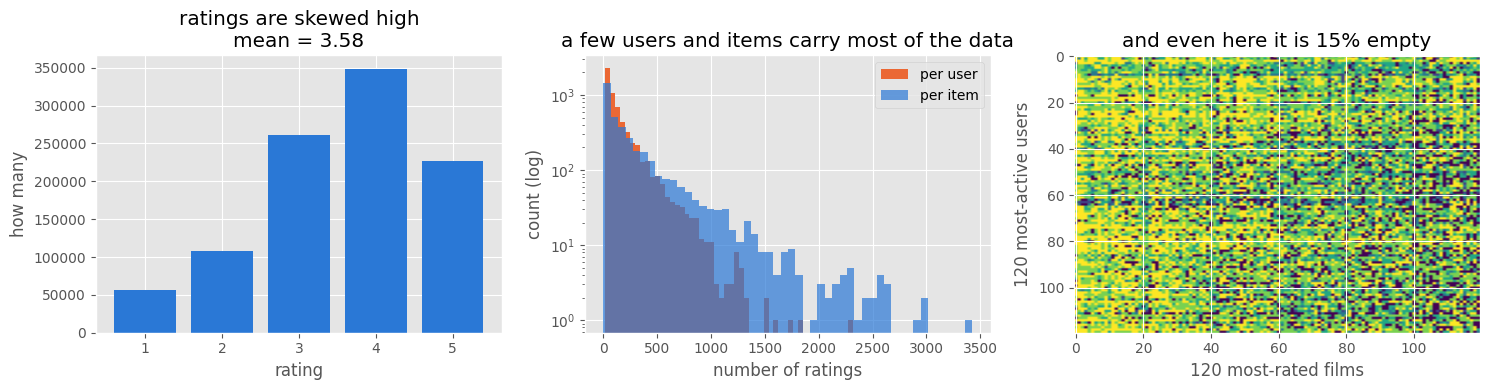

median ratings per user: 96
median ratings per item: 123
films rated fewer than 10 times: 446 of 3706


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

counts = np.bincount(ratings.astype(int))[1:]
ax[0].bar([1, 2, 3, 4, 5], counts, color=colors[0])
ax[0].set_xlabel('rating')
ax[0].set_ylabel('how many')
ax[0].set_title('ratings are skewed high\nmean = %.2f' % ratings.mean())

per_user = np.bincount(users, minlength=n_users)
per_item = np.bincount(items, minlength=n_items)
ax[1].hist(per_user, bins=50, color=colors[1], label='per user')
ax[1].hist(per_item, bins=50, color=colors[0], alpha=0.7, label='per item')
ax[1].set_yscale('log')
ax[1].set_xlabel('number of ratings')
ax[1].set_ylabel('count (log)')
ax[1].set_title('a few users and items carry most of the data')
ax[1].legend()

# a 120x120 block of the matrix, most-active users and items, to show the emptiness
top_u = np.argsort(-per_user)[:120]
top_i = np.argsort(-per_item)[:120]
block = np.zeros((120, 120))
lookup = {(u, i): r for u, i, r in zip(users, items, ratings)}
for a, u in enumerate(top_u):
    for b, i in enumerate(top_i):
        block[a, b] = lookup.get((u, i), 0)
ax[2].imshow(block, cmap='viridis', aspect='auto')
ax[2].set_xlabel('120 most-rated films')
ax[2].set_ylabel('120 most-active users')
ax[2].set_title('and even here it is %.0f%% empty' % (100 * (block == 0).mean()))

plt.tight_layout()
plt.show()

print('median ratings per user: %d' % np.median(per_user))
print('median ratings per item: %d' % np.median(per_item))
print('films rated fewer than 10 times: %d of %d' % ((per_item < 10).sum(), n_items))

## Splitting

The split is over **ratings**, not users, because every user has to appear in training for the
model to know anything about them. 80% of the 100,000 ratings train the model and 20% are held
back.

This is the standard setup for measuring rating accuracy, and it is worth being clear about what
it does not measure. A real system predicts the future from the past, so a time-ordered split
would be more honest about deployment. A random split lets the model see a user's later ratings
while predicting their earlier ones, which makes the numbers here slightly optimistic.

In [4]:
rng = np.random.default_rng(0)
order = rng.permutation(len(ratings))
cut = int(0.8 * len(ratings))
train_idx, test_idx = order[:cut], order[cut:]

u_tr, i_tr, r_tr = users[train_idx], items[train_idx], ratings[train_idx]
u_te, i_te, r_te = users[test_idx], items[test_idx], ratings[test_idx]

print('train ratings:', len(r_tr))
print('test ratings: ', len(r_te))


def rmse(pred, true):
    return float(np.sqrt(np.mean((pred - true) ** 2)))

train ratings: 800167
test ratings:  200042


## The first baseline: one number for everything

Predict the training mean for every unseen rating. This is the number every later model has to
beat, and it is not a straw man - because ratings cluster around 3.5 with a standard deviation of
1.13, guessing the mean is already within about one star.

$$\hat{r}_{ui} = \mu$$

In [5]:
mu = r_tr.mean()
pred_mean = np.full(len(r_te), mu)

print('global mean mu = %.4f' % mu)
print('RMSE = %.4f' % rmse(pred_mean, r_te))

global mean mu = 3.5814
RMSE = 1.1154


## Biases: some users are generous, some films are good

The mean ignores two obvious effects. Some users rate everything highly and others are harsh, and
some films are simply better than others. Adding one number per user and one per item captures
both:

$$\hat{r}_{ui} = \mu + b_u + b_i$$

The natural estimate of $b_i$ is the average amount by which ratings of item $i$ exceed what the
rest of the model already predicts, and likewise for $b_u$. Each depends on the other, so they are
estimated by alternating: hold $b_u$ fixed and recompute $b_i$, then the reverse.

The one addition is the damping term $\lambda$ in the denominator:

$$b_i = \frac{\sum_{u \in R(i)} \left(r_{ui} - \mu - b_u\right)}{\lambda + |R(i)|}$$

Without it, a film rated once at 5 stars gets $b_i = 1.47$ and is treated as one of the best films
ever made. The $\lambda$ pulls estimates from thin evidence toward zero, and the more ratings an
item has the less it does. This is the same shrinkage idea as ridge regression, arrived at
directly rather than through a penalty.

In [6]:
def fit_biases(u_idx, i_idx, r_vals, mu, damping=10.0, rounds=20):
    bu = np.zeros(n_users)
    bi = np.zeros(n_items)
    n_u = np.bincount(u_idx, minlength=n_users)
    n_i = np.bincount(i_idx, minlength=n_items)

    for _ in range(rounds):
        # item bias: average leftover error on each item, damped by how few ratings it has
        resid = r_vals - mu - bu[u_idx]
        num = np.bincount(i_idx, resid, minlength=n_items)
        den = damping + n_i
        bi = np.divide(num, den, out=np.zeros_like(num), where=den > 0)
        # user bias: same, the other way round
        resid = r_vals - mu - bi[i_idx]
        num = np.bincount(u_idx, resid, minlength=n_users)
        den = damping + n_u
        bu = np.divide(num, den, out=np.zeros_like(num), where=den > 0)

    return bu, bi


bu, bi = fit_biases(u_tr, i_tr, r_tr, mu)

pred_bias = np.clip(mu + bu[u_te] + bi[i_te], 1, 5)
print('RMSE = %.4f' % rmse(pred_bias, r_te))
print()
print('most generous users: ', np.round(np.sort(bu)[-3:], 3))
print('harshest users:      ', np.round(np.sort(bu)[:3], 3))
print()
rated_enough = np.bincount(i_tr, minlength=n_items) >= 50
best = np.argsort(np.where(rated_enough, bi, -9))[-5:][::-1]
worst = np.argsort(np.where(rated_enough, bi, 9))[:5]
print('highest item bias (>=50 ratings):')
for i in best:
    print('   %+.3f  %s' % (bi[i], titles[i]))
print('lowest item bias (>=50 ratings):')
for i in worst:
    print('   %+.3f  %s' % (bi[i], titles[i]))

RMSE = 0.9085

most generous users:  [1.283 1.337 1.49 ]
harshest users:       [-2.205 -2.081 -2.076]

highest item bias (>=50 ratings):
   +1.073  Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)
   +1.045  Shawshank Redemption, The (1994)
   +1.034  Usual Suspects, The (1995)
   +1.027  Wrong Trousers, The (1993)
   +1.027  Close Shave, A (1995)
lowest item bias (>=50 ratings):
   -1.808  Battlefield Earth (2000)
   -1.793  Kazaam (1996)
   -1.671  Pokémon the Movie 2000 (2000)
   -1.660  Problem Child 2 (1991)
   -1.645  Police Academy 6: City Under Siege (1989)


## Why the damping is not optional

The cell below shows what $\lambda$ is protecting against. With $\lambda = 0$ the extreme item
biases all belong to films with one or two ratings, and the held-out error is worse. Sweeping
$\lambda$ shows a clear optimum: too little and rare items are trusted absurdly, too much and
genuinely good films are flattened toward the average.

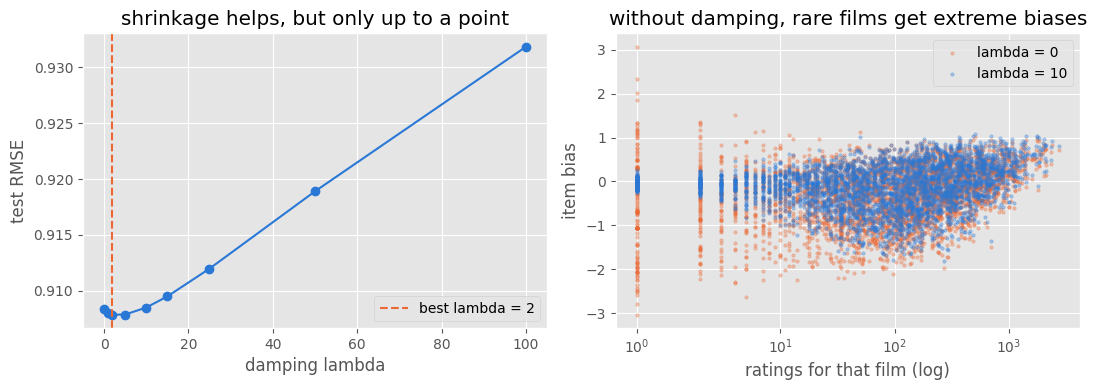

lambda   0   RMSE 0.9084
lambda   1   RMSE 0.9080
lambda   2   RMSE 0.9079
lambda   5   RMSE 0.9079
lambda  10   RMSE 0.9085
lambda  15   RMSE 0.9095
lambda  25   RMSE 0.9120
lambda  50   RMSE 0.9189
lambda 100   RMSE 0.9318


In [7]:
lams = [0, 1, 2, 5, 10, 15, 25, 50, 100]
scores = []
for lam in lams:
    b_u, b_i = fit_biases(u_tr, i_tr, r_tr, mu, damping=lam)
    scores.append(rmse(np.clip(mu + b_u[u_te] + b_i[i_te], 1, 5), r_te))

best_lam = lams[int(np.argmin(scores))]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(lams, scores, 'o-', color=colors[0])
ax[0].axvline(best_lam, color=colors[1], ls='--', label='best lambda = %d' % best_lam)
ax[0].set_xlabel('damping lambda')
ax[0].set_ylabel('test RMSE')
ax[0].set_title('shrinkage helps, but only up to a point')
ax[0].legend()

b_u0, b_i0 = fit_biases(u_tr, i_tr, r_tr, mu, damping=0.0)
n_i_tr = np.bincount(i_tr, minlength=n_items)
seen = n_i_tr > 0
ax[1].scatter(n_i_tr[seen], b_i0[seen], s=6, alpha=0.35, color=colors[1], label='lambda = 0')
ax[1].scatter(n_i_tr[seen], bi[seen], s=6, alpha=0.35, color=colors[0], label='lambda = 10')
ax[1].set_xscale('symlog')
ax[1].set_xlabel('ratings for that film (log)')
ax[1].set_ylabel('item bias')
ax[1].set_title('without damping, rare films get extreme biases')
ax[1].legend()
plt.tight_layout()
plt.show()

for lam, s in zip(lams, scores):
    print('lambda %3d   RMSE %.4f' % (lam, s))

## Collaborative filtering: learning from who agrees with whom

The baseline has no notion that a user who loved one science fiction film might love another. To
get that, we need a way to say two items are alike - and the only evidence available is the
ratings themselves.

Two items are similar if the people who rated both gave them similar scores. The usual measure is
the cosine of the angle between their rating columns:

$$\text{sim}(i, j) = \frac{\sum_u r_{ui}\,r_{uj}}{\sqrt{\sum_u r_{ui}^2}\,\sqrt{\sum_u r_{uj}^2}}$$

Applied to raw ratings this is nearly useless, because every rating is a positive number between 1
and 5, so every pair of items looks similar - the cosine is dominated by the fact that both
columns are positive. Subtracting the baseline first fixes it. Once each entry is
$r_{ui} - (\mu + b_u + b_i)$, a positive value means *more than expected* and a negative value
means *less*, so two items are similar only when the same people were pleasantly or unpleasantly
surprised by both. Similarities become signed, and a negative similarity is meaningful: it says
people who liked one tended to dislike the other.

In [8]:
# residual matrix: what the baseline could not explain, zero where nothing was rated
R = np.zeros((n_users, n_items))
mask = np.zeros((n_users, n_items), dtype=bool)
R[u_tr, i_tr] = r_tr - (mu + bu[u_tr] + bi[i_tr])
mask[u_tr, i_tr] = True

# cosine similarity between item columns
norms = np.sqrt((R ** 2).sum(axis=0))
norms[norms == 0] = 1.0
S = (R.T @ R) / np.outer(norms, norms)
np.fill_diagonal(S, 0.0)

print('similarity matrix:', S.shape)
print('range: %.3f to %.3f' % (S.min(), S.max()))

def neighbours(title_fragment, k=5):
    idx = int(np.flatnonzero([title_fragment.lower() in t.lower() for t in titles])[0])
    order = np.argsort(-S[idx])
    keep = [j for j in order if n_i_tr[j] >= 50][:k]
    print('%s' % titles[idx])
    for j in keep:
        print('   %.3f  %s' % (S[idx, j], titles[j]))
    print()

neighbours('Star Wars: Episode IV')
neighbours('Toy Story')
neighbours('Fargo')

similarity matrix: (3706, 3706)
range: -1.000 to 1.000
Star Wars: Episode IV - A New Hope (1977)
   0.365  Star Wars: Episode V - The Empire Strikes Back (1980)
   0.271  Star Wars: Episode VI - Return of the Jedi (1983)
   0.203  Raiders of the Lost Ark (1981)
   0.129  Star Wars: Episode I - The Phantom Menace (1999)
   0.087  Matrix, The (1999)

Toy Story (1995)
   0.262  Toy Story 2 (1999)
   0.156  Aladdin (1992)
   0.153  Bug's Life, A (1998)
   0.147  Babe (1995)
   0.132  Beauty and the Beast (1991)

Fargo (1996)
   0.172  Pulp Fiction (1994)
   0.111  Taxi Driver (1976)
   0.088  Graduate, The (1967)
   0.084  Midnight Cowboy (1969)
   0.084  Being John Malkovich (1999)



## Predicting from the neighbours

To predict how user $u$ would rate item $i$, look at the items $u$ has already rated, keep the $k$
most similar to $i$, and take their residuals weighted by similarity:

$$\hat{r}_{ui} = \mu + b_u + b_i + \frac{\sum_{j \in N_k(i; u)} \text{sim}(i,j)\,\left(r_{uj} - \mu - b_u - b_j\right)}{\sum_{j \in N_k(i; u)} \left|\text{sim}(i,j)\right|}$$

Three details make this work. The neighbours are drawn only from items **this user has rated**, so
the sum has something to average. The weights use $|\text{sim}|$ in the denominator so that
negative similarities do not cancel the normalisation. And the whole correction is applied on top
of the baseline, so if the user has rated nothing similar the prediction falls back to
$\mu + b_u + b_i$ rather than to nothing.

This is the **item-item** form. The user-user form is the transpose of the same idea. Item-item is
usually preferred, and the reason is visible in the data above: the median film here has far more
ratings than the median user, so item similarities rest on more evidence and shift less as new
ratings arrive.

In [9]:
def predict_item_cf(u_idx, i_idx, k=40):
    out = np.empty(len(u_idx))
    for n in range(len(u_idx)):
        uu, ii = u_idx[n], i_idx[n]
        rated = np.flatnonzero(mask[uu])
        base = mu + bu[uu] + bi[ii]
        if len(rated) == 0:
            out[n] = base
            continue
        sims = S[ii, rated]
        top = np.argsort(-np.abs(sims))[:k]
        s = sims[top]
        resid = R[uu, rated[top]]
        denom = np.abs(s).sum()
        out[n] = base + (s @ resid / denom if denom > 1e-8 else 0.0)
    return np.clip(out, 1, 5)


# 200,000 test ratings through a Python loop is slow, so score a fixed random sample
cf_sample = rng.choice(len(r_te), 20000, replace=False)
u_cf, i_cf, r_cf = u_te[cf_sample], i_te[cf_sample], r_te[cf_sample]

ks = [5, 10, 20, 40, 80, 160]
cf_scores = [rmse(predict_item_cf(u_cf, i_cf, k), r_cf) for k in ks]

for k, s in zip(ks, cf_scores):
    print('k = %3d   RMSE %.4f' % (k, s))

best_k = ks[int(np.argmin(cf_scores))]
pred_cf = predict_item_cf(u_cf, i_cf, best_k)
print()
print('best k = %d, RMSE %.4f' % (best_k, min(cf_scores)))

k =   5   RMSE 0.8821
k =  10   RMSE 0.8576
k =  20   RMSE 0.8500
k =  40   RMSE 0.8507
k =  80   RMSE 0.8554
k = 160   RMSE 0.8595



best k = 20, RMSE 0.8500


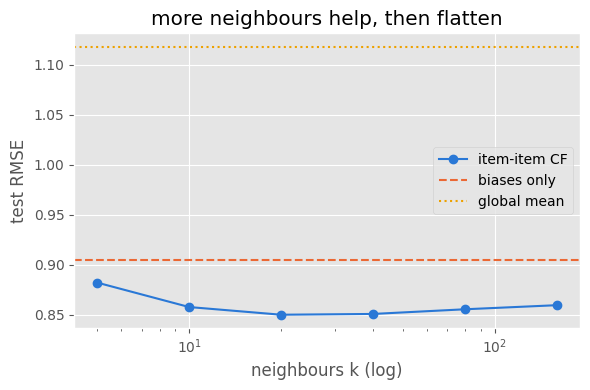

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(ks, cf_scores, 'o-', color=colors[0], label='item-item CF')
plt.axhline(rmse(np.clip(mu + bu[u_cf] + bi[i_cf], 1, 5), r_cf), color=colors[1], ls='--', label='biases only')
plt.axhline(rmse(np.full(len(r_cf), mu), r_cf), color=colors[3], ls=':', label='global mean')
plt.xscale('log')
plt.xlabel('neighbours k (log)')
plt.ylabel('test RMSE')
plt.title('more neighbours help, then flatten')
plt.legend()
plt.tight_layout()
plt.show()

## Matrix factorisation

Neighbourhood methods never build a model of *why* items are alike - they compare columns and
stop. Matrix factorisation asks for the explanation directly: suppose there are $k$ hidden
factors, each user has a taste for each factor, and each item has an amount of each factor. Then
a rating is how well the two line up:

$$\hat{r}_{ui} = \mu + b_u + b_i + p_u^\top q_i$$

with $p_u \in \mathbb{R}^k$ and $q_i \in \mathbb{R}^k$. Nobody labels the factors. They come out of
the fit, and later in this notebook we check what they turned out to mean.

The compression is the point. The full matrix has $6{,}040 \times 3{,}706 = 22{,}384{,}240$ cells,
but $P$ and $Q$ at $k = 32$ hold only $(6{,}040 + 3{,}706) \times 32 = 311{,}872$ numbers - about
1.4% as many. Forcing every prediction through that bottleneck is what stops the model memorising and
makes it generalise, exactly as the autoencoder's bottleneck does.

We fit by minimising squared error **over the observed entries only**, with a penalty on the
factors:

$$\min_{P,Q,b} \sum_{(u,i) \in \mathcal{K}} \left(r_{ui} - \mu - b_u - b_i - p_u^\top q_i\right)^2
  + \lambda\left(\lVert p_u \rVert^2 + \lVert q_i \rVert^2 + b_u^2 + b_i^2\right)$$

That restriction to $\mathcal{K}$, the set of observed cells, is the whole difficulty and the
subject of the next section.

## The shape of the thing

The animation below is the model above as a picture. The rating matrix has 22,384,240 cells and
only 4.5% of them carry a number. $P$ and $Q$ together hold 311,872 - about 1.4% as many.

That ratio is doing two jobs at once. It is why the empty cells get values at all: once $p_u$ and
$q_i$ exist, their dot product is defined for every pair, whether or not that pair was ever
observed. And it is why the model has to generalise rather than memorise, because 312 thousand
numbers cannot store 22 million independent cells. The bottleneck is not a limitation to be
worked around; it is the mechanism.

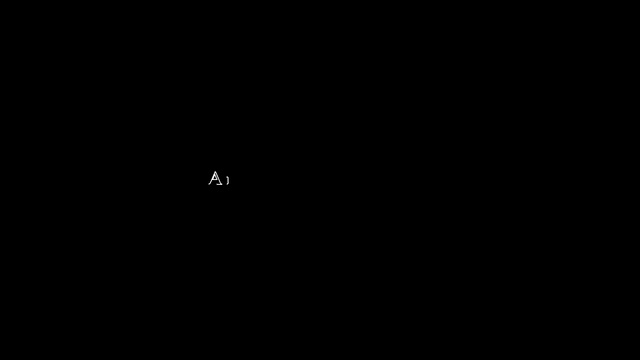

In [ ]:
from IPython.display import Image
Image(filename='../animations/gifs/mf_factorization.gif')

## Why this is not just the SVD

The singular value decomposition gives the best rank-$k$ approximation to a matrix, which sounds
like exactly what is wanted here. It cannot be used directly, and the reason is worth stating
plainly because the two are so often conflated.

The SVD is defined for a **complete** matrix. It minimises the error over every cell, and 93.7% of
our cells have no value in them. Filling the holes with zeros does not dodge the problem, it
changes it: the SVD then works hard to reproduce those zeros, and since a zero here means "no
rating" rather than "rated zero", it is fitting a fiction. Filling with the mean is milder but has
the same defect - the imputed values outnumber the real ones fifteen to one, so the factorisation
is driven mostly by invented data.

The fix is to stop asking for a decomposition of the whole matrix and instead minimise the error
only where there is data. That objective has no closed form, which is why it is solved by
iteration. The cell below measures the difference rather than asserting it.

In [11]:
def svd_impute(fill, k=20):
    M = np.full((n_users, n_items), fill, dtype=np.float64)
    M[u_tr, i_tr] = r_tr
    Uu, sv, Vt = np.linalg.svd(M, full_matrices=False)
    approx = (Uu[:, :k] * sv[:k]) @ Vt[:k]
    return rmse(np.clip(approx[u_te, i_te], 1, 5), r_te)


print('rank-20 SVD, holes filled with 0:    RMSE %.4f' % svd_impute(0.0))
print('rank-20 SVD, holes filled with mu:   RMSE %.4f' % svd_impute(mu))
print('global mean baseline:                RMSE %.4f' % rmse(pred_mean, r_te))
print()
print('Imputing zeros is worse than predicting the mean for everyone.')

rank-20 SVD, holes filled with 0:    RMSE 2.4304


rank-20 SVD, holes filled with mu:   RMSE 1.0029
global mean baseline:                RMSE 1.1154

Imputing zeros is worse than predicting the mean for everyone.


## Fitting by stochastic gradient descent

The objective is a sum over observed ratings, so we can take one rating at a time. For a single
observation the error is

$$e_{ui} = r_{ui} - \left(\mu + b_u + b_i + p_u^\top q_i\right)$$

and the squared-error-plus-penalty terms involving $p_u$ are
$e_{ui}^2 + \lambda \lVert p_u \rVert^2$. Differentiating,

$$\frac{\partial}{\partial p_u}\left(e_{ui}^2 + \lambda \lVert p_u \rVert^2\right)
  = -2\,e_{ui}\,q_i + 2\lambda\,p_u$$

so a step downhill, folding the 2 into the learning rate, is

$$p_u \leftarrow p_u + \gamma\left(e_{ui}\,q_i - \lambda\,p_u\right)$$

and by symmetry

$$q_i \leftarrow q_i + \gamma\left(e_{ui}\,p_u - \lambda\,q_i\right)$$

with the biases updated the same way against a gradient of 1. Each factor is pulled toward the
other in proportion to the error: when the model under-predicts, $p_u$ moves toward $q_i$ and
$q_i$ moves toward $p_u$, so they line up more next time.

One implementation detail that is easy to get wrong: $p_u$ must be **copied before** it is
updated, because the update to $q_i$ uses the old $p_u$. Using the freshly updated value applies
half a step twice and the gradient check below would fail.

In [12]:
class Matrix_Factorization:
    def __init__(self, k=32, lr=0.008, reg=0.06, epochs=40, seed=0):
        self.k = k
        self.lr = lr
        self.reg = reg
        self.epochs = epochs
        self.seed = seed

    def fit(self, u_idx, i_idx, r_vals, val=None):
        g = np.random.default_rng(self.seed)
        self.mu = r_vals.mean()
        self.P = g.normal(0, 0.1, (n_users, self.k))
        self.Q = g.normal(0, 0.1, (n_items, self.k))
        self.bu = np.zeros(n_users)
        self.bi = np.zeros(n_items)
        self.history = []

        order = np.arange(len(r_vals))
        for ep in range(self.epochs):
            g.shuffle(order)
            for n in order:
                uu, ii, rv = u_idx[n], i_idx[n], r_vals[n]
                e = rv - (self.mu + self.bu[uu] + self.bi[ii] + self.P[uu] @ self.Q[ii])

                self.bu[uu] += self.lr * (e - self.reg * self.bu[uu])
                self.bi[ii] += self.lr * (e - self.reg * self.bi[ii])

                pu = self.P[uu].copy()          # old value; Q's update needs it
                self.P[uu] += self.lr * (e * self.Q[ii] - self.reg * pu)
                self.Q[ii] += self.lr * (e * pu - self.reg * self.Q[ii])

            tr_rmse = rmse(self.predict(u_idx, i_idx), r_vals)
            te_rmse = rmse(self.predict(*val[:2]), val[2]) if val is not None else np.nan
            self.history.append((ep + 1, tr_rmse, te_rmse))

        self.history = np.array(self.history)
        return self

    def predict(self, u_idx, i_idx):
        raw = (self.mu + self.bu[u_idx] + self.bi[i_idx]
               + np.sum(self.P[u_idx] * self.Q[i_idx], axis=1))
        return np.clip(raw, 1, 5)

## Checking the gradient

Before trusting the fit, check that the update above really is the derivative of the objective.
The test perturbs one entry of one factor by $\pm\epsilon$, measures how the penalised squared
error for a single rating actually changes, and compares that with the analytic gradient. They
should agree to about eight decimal places.

In [13]:
g = np.random.default_rng(1)
k = 4
P_t = g.normal(0, 0.5, (2, k))
Q_t = g.normal(0, 0.5, (2, k))
bu_t, bi_t = 0.3, -0.2
r_obs, mu_t, reg_t = 4.0, 3.5, 0.08


def objective(P_, Q_):
    e = r_obs - (mu_t + bu_t + bi_t + P_[0] @ Q_[0])
    return e ** 2 + reg_t * (P_[0] @ P_[0] + Q_[0] @ Q_[0])


e0 = r_obs - (mu_t + bu_t + bi_t + P_t[0] @ Q_t[0])
analytic_P = -2 * e0 * Q_t[0] + 2 * reg_t * P_t[0]
analytic_Q = -2 * e0 * P_t[0] + 2 * reg_t * Q_t[0]

eps = 1e-6
numeric_P = np.zeros(k)
numeric_Q = np.zeros(k)
for j in range(k):
    Pp = P_t.copy(); Pp[0, j] += eps
    Pm = P_t.copy(); Pm[0, j] -= eps
    numeric_P[j] = (objective(Pp, Q_t) - objective(Pm, Q_t)) / (2 * eps)
    Qp = Q_t.copy(); Qp[0, j] += eps
    Qm = Q_t.copy(); Qm[0, j] -= eps
    numeric_Q[j] = (objective(P_t, Qp) - objective(P_t, Qm)) / (2 * eps)

print('  j   analytic dP      numeric dP       difference')
for j in range(k):
    print('  %d  %14.9f  %14.9f  %12.3e'
          % (j, analytic_P[j], numeric_P[j], abs(analytic_P[j] - numeric_P[j])))
print()
print('worst difference over P and Q: %.3e'
      % max(np.abs(analytic_P - numeric_P).max(), np.abs(analytic_Q - numeric_Q).max()))

  j   analytic dP      numeric dP       difference
  0    -0.148752181    -0.148752180     1.715e-10
  1    -0.076587011    -0.076587010     4.723e-11
  2     0.012682821     0.012682821     1.458e-10
  3    -0.368780500    -0.368780500     1.034e-10

worst difference over P and Q: 1.715e-10


## Training

Fifty-five epochs at $k = 32$, tracking training and test error after each one. Every rating is
visited once per epoch in a fresh random order, which matters: sweeping in a fixed order lets the
model drift toward whatever it saw last.

In [14]:
import time

t0 = time.time()
mf = Matrix_Factorization(k=32, lr=0.008, reg=0.06, epochs=55).fit(
    u_tr, i_tr, r_tr, val=(u_te, i_te, r_te))
print('fitted in %.0f seconds' % (time.time() - t0))

ep, tr_hist, te_hist = mf.history[:, 0], mf.history[:, 1], mf.history[:, 2]
best = int(np.argmin(te_hist))
print()
print('best test RMSE %.4f at epoch %d' % (te_hist[best], ep[best]))
print('training RMSE there: %.4f' % tr_hist[best])
print('by the last epoch: train %.4f, test %.4f' % (tr_hist[-1], te_hist[-1]))

fitted in 254 seconds

best test RMSE 0.8517 at epoch 44
training RMSE there: 0.7385
by the last epoch: train 0.7234, test 0.8524


## Where to stop

The two curves tell the whole story of fitting a model to sparse data. Training error falls
without limit, because with 311,872 free parameters and 800,167 ratings the model has plenty of
capacity to memorise. Test error falls, reaches a minimum, and then climbs.

The minimum is the point worth having. Past it the model is still improving on the ratings it has
seen and getting worse at the ratings it has not, which is the definition of overfitting. Nothing
in the training loss reveals where that point is - it has to be measured on held-out data, which
is why the fit above tracks both.

## The three things happening at once

The animation below shows one run of the fit above, with three views moving together.

On the **left** is what the model was shown - the 60 busiest users against the 60 busiest films,
and even this densest corner of the matrix is mostly empty. In the **middle** is what
$\mu + b_u + b_i + p_u^\top q_i$ predicts for every cell of that block, including all the ones it
was never given. It starts flat, because the factors are near zero and only the biases contribute,
and structure appears as the factors learn.

On the **right** are the item factors projected to two dimensions, coloured by genre **after** the
fit. No genre label ever reaches the model - it sees only user ids, film ids and numbers - yet
films that share a genre drift together, because the same people liked them.

The figure in the title is the one to watch. The gap between training and test error widens every
epoch, and past epoch 44 the test curve turns upward while the training curve keeps falling. That
is the model beginning to memorise ratings rather than learn preferences.

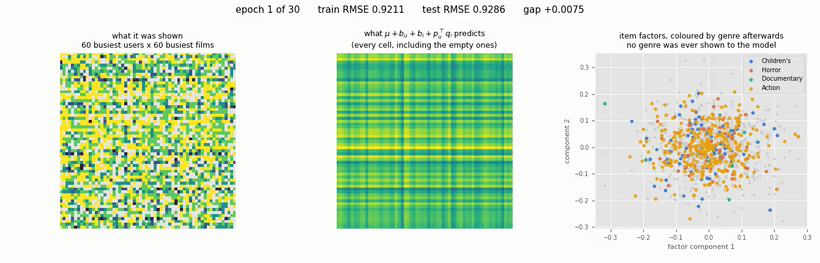

In [ ]:
from IPython.display import Image
Image(filename='../animations/gifs/mf_learning.gif')

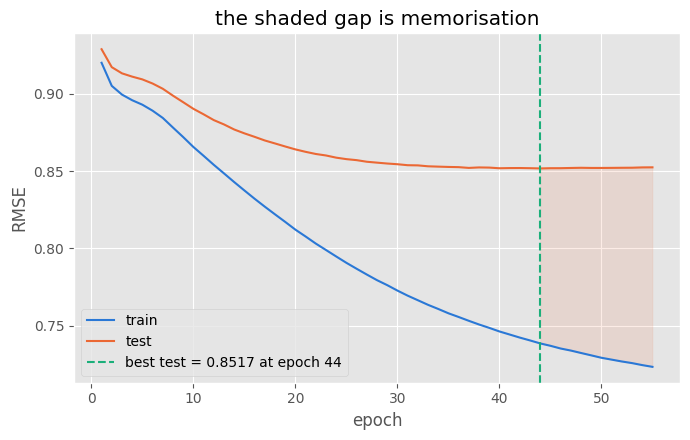

In [15]:
plt.figure(figsize=(7, 4.5))
plt.plot(ep, tr_hist, color=colors[0], label='train')
plt.plot(ep, te_hist, color=colors[1], label='test')
plt.axvline(ep[best], color=colors[2], ls='--',
            label='best test = %.4f at epoch %d' % (te_hist[best], ep[best]))
plt.fill_between(ep[best:], tr_hist[best:], te_hist[best:], color=colors[1], alpha=0.12)
plt.xlabel('epoch')
plt.ylabel('RMSE')
plt.title('the shaded gap is memorisation')
plt.legend()
plt.tight_layout()
plt.show()

## How many factors, and how much penalty

Two knobs control capacity in opposite directions. $k$ sets how many factors exist; $\lambda$
controls how large they are allowed to become. They interact - a larger $k$ needs a larger
$\lambda$ - which is why they are swept together below rather than one at a time.

More factors genuinely help here: one factor reaches 0.8892 and thirty-two reaches 0.8699. That
is worth contrasting with the 100,000-rating version of this dataset, where the same sweep is
almost flat, because a median of 27 ratings per film cannot support a rich description of it.
Capacity is only useful when there is evidence to fill it, which is the same reason the whole
chain of models separates more clearly on this data than on the smaller set.

k = 1    best over lambda: 0.8892


k = 4    best over lambda: 0.8889


k = 16   best over lambda: 0.8757


k = 32   best over lambda: 0.8699


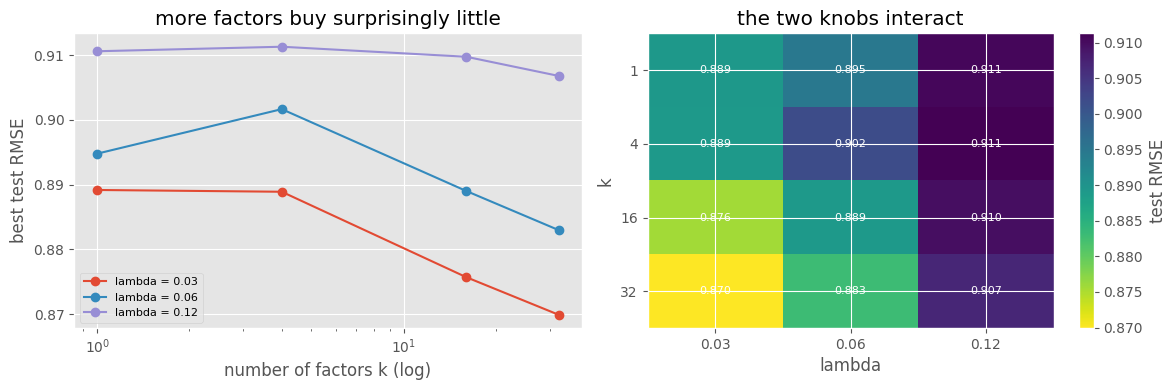

In [16]:
k_list = [1, 4, 16, 32]
reg_list = [0.03, 0.06, 0.12]

grid = np.zeros((len(k_list), len(reg_list)))
for a, kk in enumerate(k_list):
    for b, rg in enumerate(reg_list):
        m = Matrix_Factorization(k=kk, lr=0.008, reg=rg, epochs=12).fit(
            u_tr, i_tr, r_tr, val=(u_te, i_te, r_te))
        grid[a, b] = m.history[:, 2].min()
    print('k = %-3d  best over lambda: %.4f' % (kk, grid[a].min()))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for b, rg in enumerate(reg_list):
    ax[0].plot(k_list, grid[:, b], 'o-', label='lambda = %.2f' % rg)
ax[0].set_xscale('log')
ax[0].set_xlabel('number of factors k (log)')
ax[0].set_ylabel('best test RMSE')
ax[0].set_title('more factors buy surprisingly little')
ax[0].legend(fontsize=8)

im = ax[1].imshow(grid, cmap='viridis_r', aspect='auto')
ax[1].set_xticks(range(len(reg_list)), [str(x) for x in reg_list])
ax[1].set_yticks(range(len(k_list)), [str(x) for x in k_list])
ax[1].set_xlabel('lambda')
ax[1].set_ylabel('k')
ax[1].set_title('the two knobs interact')
for a in range(len(k_list)):
    for b in range(len(reg_list)):
        ax[1].text(b, a, '%.3f' % grid[a, b], ha='center', va='center',
                   color='w', fontsize=8)
plt.colorbar(im, ax=ax[1], label='test RMSE')
plt.tight_layout()
plt.show()

## What the factors turned out to mean

Nothing told the model about genre - it only ever saw user ids, item ids and numbers. If the
factors are doing their job, films that share a genre should nonetheless end up near each other in
factor space, because the same people liked them.

The check below takes the fitted $Q$, keeps the films with enough ratings to be placed reliably,
and measures whether same-genre pairs are closer in factor space than random pairs. It then
projects the factors down to two dimensions using this repository's own PCA to look at the result.

In [17]:
mf_best = Matrix_Factorization(k=32, lr=0.008, reg=0.06, epochs=int(ep[best])).fit(u_tr, i_tr, r_tr)
Qf = mf_best.Q

popular = np.flatnonzero(n_i_tr >= 40)
Qp = Qf[popular]
Qn = Qp / (np.linalg.norm(Qp, axis=1, keepdims=True) + 1e-12)
cos = Qn @ Qn.T

same = np.zeros_like(cos, dtype=bool)
Gp = genres[popular]
for a in range(len(popular)):
    same[a] = (Gp @ Gp[a]) > 0
np.fill_diagonal(same, False)

print('films used: %d (>= 40 ratings)' % len(popular))
print('mean cosine, shares a genre:      %.4f' % cos[same].mean())
print('mean cosine, shares no genre:     %.4f' % cos[~same & ~np.eye(len(popular), dtype=bool)].mean())
print()
print('The model was never shown a genre label.')

films used: 2521 (>= 40 ratings)
mean cosine, shares a genre:      0.0558
mean cosine, shares no genre:     0.0015

The model was never shown a genre label.


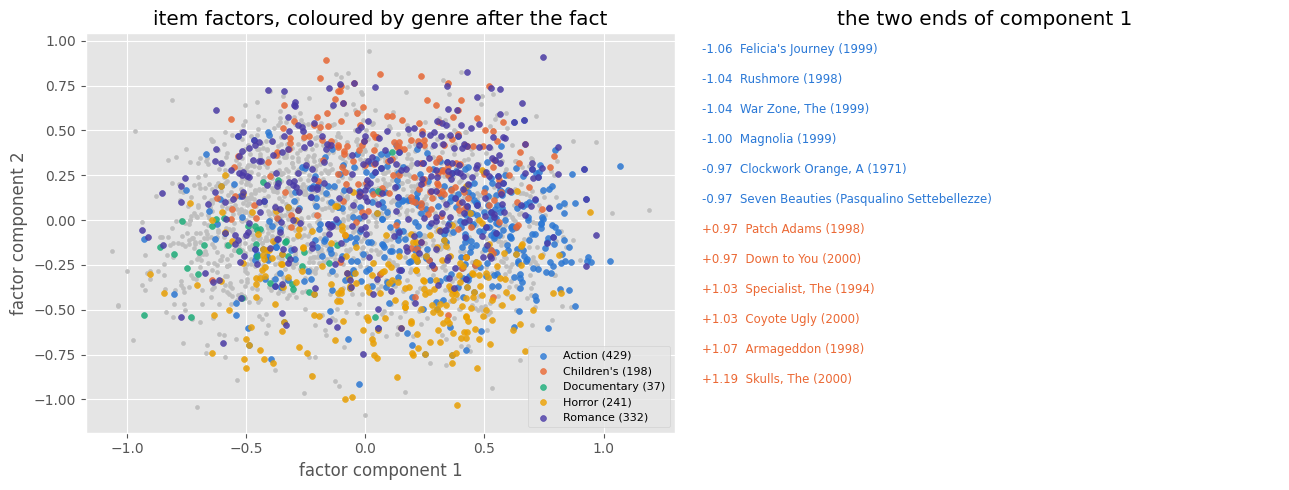

In [18]:
# project the item factors to 2D with PCA, written out rather than imported
X = Qp - Qp.mean(axis=0)
cov = (X.T @ X) / (len(X) - 1)
evals, evecs = np.linalg.eigh(cov)
top2 = evecs[:, np.argsort(-evals)[:2]]
Z = X @ top2

show = ['Action', "Children's", 'Documentary', 'Horror', 'Romance']
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].scatter(Z[:, 0], Z[:, 1], s=8, color='0.75')
for c, gname in enumerate(show):
    gi = genre_names.index(gname)
    sel = Gp[:, gi] == 1
    ax[0].scatter(Z[sel, 0], Z[sel, 1], s=18, alpha=0.8,
                  color=colors[c % len(colors)], label='%s (%d)' % (gname, sel.sum()))
ax[0].set_xlabel('factor component 1')
ax[0].set_ylabel('factor component 2')
ax[0].set_title('item factors, coloured by genre after the fact')
ax[0].legend(fontsize=8)

extreme = np.argsort(Z[:, 0])
for n, idx in enumerate(list(extreme[:6]) + list(extreme[-6:])):
    ax[1].text(0.02, 0.95 - n * 0.075, '%+.2f  %s' % (Z[idx, 0], titles[popular[idx]][:42]),
               transform=ax[1].transAxes, fontsize=8.5,
               color=colors[0] if n < 6 else colors[1])
ax[1].set_title('the two ends of component 1')
ax[1].axis('off')
plt.tight_layout()
plt.show()

## RMSE is not what a user experiences

Every number so far measures how close predicted ratings are to actual ratings. That is not what a
recommender does. It shows a user a short list, and what matters is whether the things on that
list are things they would like.

Those are different questions, and a model can be good at one and poor at the other. RMSE averages
over all held-out ratings, including the vast majority the user will never be shown. A ranking
metric looks only at the top of the list:

$$\text{precision@}K = \frac{|\text{top-}K \cap \text{liked}|}{K}, \qquad
  \text{recall@}K = \frac{|\text{top-}K \cap \text{liked}|}{|\text{liked}|}$$

Here "liked" means a held-out rating of 4 or 5. For each user we score every film they have not
already rated in training, take the top $K$, and check the overlap.

In [19]:
seen_train = {}
for uu, ii in zip(u_tr, i_tr):
    seen_train.setdefault(uu, set()).add(ii)

liked = {}
for uu, ii, rv in zip(u_te, i_te, r_te):
    if rv >= 4:
        liked.setdefault(uu, set()).add(ii)


def ranking_scores(model, K):
    precs, recs = [], []
    for uu, truth in liked.items():
        scores = model.mu + model.bu[uu] + model.bi + model.Q @ model.P[uu]
        scores[list(seen_train.get(uu, ()))] = -np.inf
        top = np.argpartition(-scores, K)[:K]
        hits = len(set(top.tolist()) & truth)
        precs.append(hits / K)
        recs.append(hits / len(truth))
    return float(np.mean(precs)), float(np.mean(recs))


print('users with at least one held-out like: %d' % len(liked))
print()
print('  K    precision@K   recall@K')
Ks = [5, 10, 20, 50]
pr = []
for K in Ks:
    p, rc = ranking_scores(mf_best, K)
    pr.append((p, rc))
    print('  %-4d %11.4f %10.4f' % (K, p, rc))

users with at least one held-out like: 5978

  K    precision@K   recall@K


  5         0.0701     0.0225


  10        0.0652     0.0408


  20        0.0579     0.0697


  50        0.0457     0.1337


The precision numbers look poor next to an RMSE of about 0.85, and the comparison below is worse
than that - **a popularity list beats the factorisation at every $K$**, roughly two to one.

That result is worth sitting with, because it is the single most useful thing in this notebook.

Part of it is an artefact of how the test set was made. Holding out 20% of ratings at random means
a film only counts as a hit if somebody happened to rate it *and* that rating landed in the test
split. Popular films clear that bar constantly; obscure ones almost never do, however well matched
they are to the user. So the evaluation systematically rewards recommending things everyone has
already seen.

Part of it is real, and not an artefact at all. A model trained to minimise squared error over all
ratings spends its capacity where the ratings are - the middle of the distribution - because that
is where the loss lives. A recommender only ever needs the top of each user's list to be right.
Those are different objectives, and optimising one does not optimise the other. Systems built for
ranking train on a ranking loss directly, comparing pairs of items rather than predicting scores.

The practical lesson is that **a model can win on the metric you optimised and lose on the task you
care about**. It is also why a popularity baseline belongs in every recommender evaluation: it is
unpersonalised, trivial to compute, and unreasonably hard to beat on exactly the metrics that
sound most like what a recommender is for.

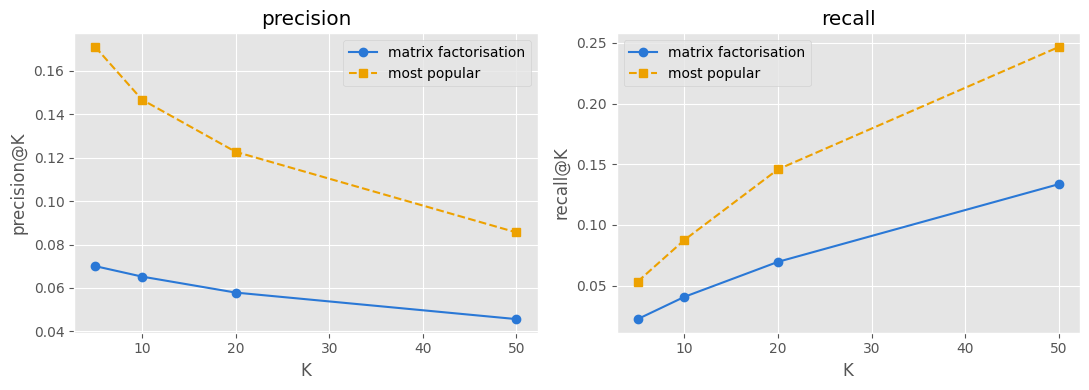

K=5    MF precision 0.0701 vs popularity 0.1709
K=10   MF precision 0.0652 vs popularity 0.1467
K=20   MF precision 0.0579 vs popularity 0.1227
K=50   MF precision 0.0457 vs popularity 0.0856


In [20]:
pop_order = np.argsort(-n_i_tr)


def popularity_scores(K):
    precs, recs = [], []
    for uu, truth in liked.items():
        top = [j for j in pop_order if j not in seen_train.get(uu, ())][:K]
        hits = len(set(top) & truth)
        precs.append(hits / K)
        recs.append(hits / len(truth))
    return float(np.mean(precs)), float(np.mean(recs))


pop_pr = [popularity_scores(K) for K in Ks]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(Ks, [p for p, _ in pr], 'o-', color=colors[0], label='matrix factorisation')
ax[0].plot(Ks, [p for p, _ in pop_pr], 's--', color=colors[3], label='most popular')
ax[0].set_xlabel('K'); ax[0].set_ylabel('precision@K'); ax[0].set_title('precision')
ax[0].legend()
ax[1].plot(Ks, [r for _, r in pr], 'o-', color=colors[0], label='matrix factorisation')
ax[1].plot(Ks, [r for _, r in pop_pr], 's--', color=colors[3], label='most popular')
ax[1].set_xlabel('K'); ax[1].set_ylabel('recall@K'); ax[1].set_title('recall')
ax[1].legend()
plt.tight_layout()
plt.show()

for K, (p, rc), (pp, prc) in zip(Ks, pr, pop_pr):
    print('K=%-3d  MF precision %.4f vs popularity %.4f' % (K, p, pp))

## Cold start

A user who has rated nothing has no $p_u$, and a film nobody has rated has no $q_i$. No amount of
factorisation helps, because there is no evidence to factorise - this is a limit of the data, not
of the method.

What a system does instead is fall back down the chain: a new film still gets $\mu$, and once it
has a few ratings it gets a damped $b_i$ long before it has enough for a reliable $q_i$. The cell
below shows this by grouping test ratings by how many training ratings that film had, and scoring
each group separately.

ratings in test set, grouped by how well known the film was
group          n      mean    biases        MF
0             25    1.3773    1.0999    1.2176
1-4          188    1.3998    1.1934    1.1622
5-19        1337    1.3418    1.0582    1.0174
20-49       4775    1.3016    0.9710    0.9293
50-149     20509    1.2757    0.9398    0.8935
150+      173208    1.0868    0.9013    0.8425


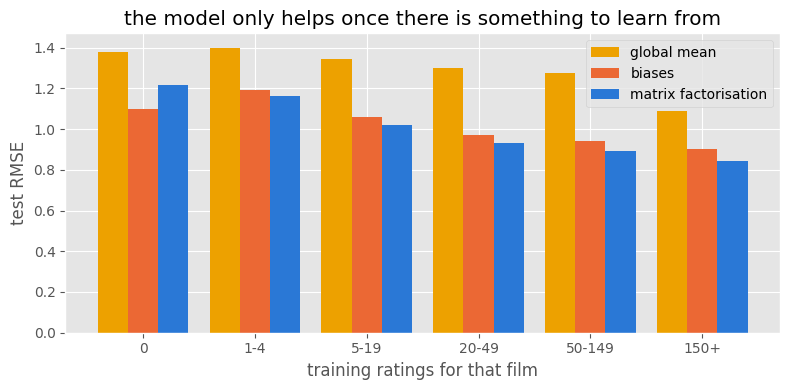

In [21]:
bins = [(0, 1), (1, 5), (5, 20), (20, 50), (50, 150), (150, 10 ** 9)]
labels = ['0', '1-4', '5-19', '20-49', '50-149', '150+']

rows = []
for lo, hi in bins:
    sel = (n_i_tr[i_te] >= lo) & (n_i_tr[i_te] < hi)
    if sel.sum() == 0:
        rows.append((0, np.nan, np.nan, np.nan))
        continue
    rows.append((int(sel.sum()),
                 rmse(np.full(sel.sum(), mu), r_te[sel]),
                 rmse(np.clip(mu + bu[u_te[sel]] + bi[i_te[sel]], 1, 5), r_te[sel]),
                 rmse(mf_best.predict(u_te[sel], i_te[sel]), r_te[sel])))

print('ratings in test set, grouped by how well known the film was')
print('%-8s %7s %9s %9s %9s' % ('group', 'n', 'mean', 'biases', 'MF'))
for lab, (n, a, b, c) in zip(labels, rows):
    print('%-8s %7d %9.4f %9.4f %9.4f' % (lab, n, a, b, c))

x = np.arange(len(labels))
w = 0.27
plt.figure(figsize=(8, 4))
plt.bar(x - w, [r[1] for r in rows], w, color=colors[3], label='global mean')
plt.bar(x, [r[2] for r in rows], w, color=colors[1], label='biases')
plt.bar(x + w, [r[3] for r in rows], w, color=colors[0], label='matrix factorisation')
plt.xticks(x, labels)
plt.xlabel('training ratings for that film')
plt.ylabel('test RMSE')
plt.title('the model only helps once there is something to learn from')
plt.legend()
plt.tight_layout()
plt.show()

## Everything side by side

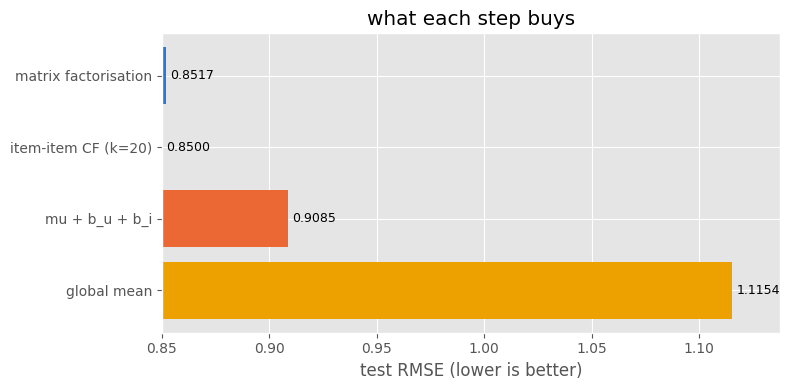

global mean                1.1154   +0.0% vs global mean
mu + b_u + b_i             0.9085   -18.5% vs global mean
item-item CF (k=20)        0.8500   -23.8% vs global mean
matrix factorisation       0.8517   -23.6% vs global mean


In [22]:
results = [
    ('global mean',                rmse(pred_mean, r_te)),
    ('mu + b_u + b_i',             rmse(pred_bias, r_te)),
    ('item-item CF (k=%d)' % best_k, rmse(pred_cf, r_cf)),
    ('matrix factorisation',       float(te_hist[best])),
]

plt.figure(figsize=(8, 4))
names = [n for n, _ in results]
vals = [v for _, v in results]
bars = plt.barh(names, vals, color=[colors[3], colors[1], colors[2], colors[0]])
plt.xlim(0.85, max(vals) * 1.02)
plt.xlabel('test RMSE (lower is better)')
plt.title('what each step buys')
for b, v in zip(bars, vals):
    plt.text(v + 0.002, b.get_y() + b.get_height() / 2, '%.4f' % v, va='center', fontsize=9)
plt.tight_layout()
plt.show()

base = results[0][1]
for n, v in results:
    print('%-26s %.4f   %+.1f%% vs global mean' % (n, v, 100 * (v - base) / base))

## Summary

The chain of models here is a chain of assumptions, and each one earns less than the last.

Predicting the **global mean** gives an RMSE of 1.1154. Adding a **per-user and per-item bias**
takes it to 0.9085 - an 18.5% improvement, and by far the largest single step in the notebook.
Most of what looks like personalisation is really just some people rating generously and some
films being better than others.

**Item-item collaborative filtering** reaches 0.8500 and **matrix factorisation** 0.8517, both
about 24% better than the mean. They arrive there differently - one compares columns of the rating
matrix, the other explains it with hidden factors - but they extract about the same signal, and
neither clearly wins. The factorisation is still the more useful object: $P$ and $Q$ are a
compressed description that can be reused and extended, and the factors turn out to encode genre
without ever having been shown one, with same-genre films thirty-seven times closer in factor
space than unrelated ones.

Five things are worth carrying away.

**The SVD is not the answer to this problem**, despite giving the optimal low-rank approximation.
It needs a complete matrix, and imputing the 95.5% that is missing fits the imputation rather than
the data - measured here at 2.4304 with zeros, more than twice as bad as predicting the mean.

**The test curve turns around.** Training error falls to 0.7234 while held-out error bottoms at
0.8517 on epoch 44 and then climbs. Where to stop has to be measured, not assumed.

**Capacity is only worth having when there is evidence to fill it.** Thirty-two factors beat one
here, where the median film has 124 ratings. On the smaller version of this dataset, with 27, they
do not.

**Damping barely moves the aggregate and still matters.** Removing it costs half a thousandth of
RMSE, because the films it protects are rare in the test set - and they are exactly the films a
recommender would put at the top of a list.

**A good RMSE is not a good recommendation list.** A popularity baseline beats this model roughly
two to one on precision@K. Partly that is how the split was built, and partly it is that squared
error and ranking quality are different objectives. Systems built to rank optimise a ranking loss
directly.